###  import  the  libararies    


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 50)
plt.style.use('seaborn-v0_8')


###  load  the  the  data sets   

In [ ]:
df = pd.read_parquet('../data/processed/train_clean.parquet')

print(f"✅ Data loaded")
print(f"   Shape  : {df.shape}")
print(f"   Fraud  : {df['isFraud'].sum():,} ({df['isFraud'].mean()*100:.2f}%)")
print(f"\nColumns available:")
print(df.columns.tolist()[:20], "...")    

✅ Data loaded
   Shape  : (590540, 222)
   Fraud  : 20,663 (3.50%)

Columns available:
['TransactionID', 'isFraud', 'TransactionDT', 'TransactionAmt', 'ProductCD', 'card1', 'card2', 'card3', 'card4', 'card5', 'card6', 'addr1', 'addr2', 'P_emaildomain', 'C1', 'C2', 'C3', 'C4', 'C5', 'C6'] ...


## 2. Time-Based Features   
`TransactionDT` is the number of seconds since some reference point.
We extract hour, day, and weekend flags from it.
Fraud patterns often vary by time — e.g. more fraud at night or on weekends.

In [4]:
# Hour of day (0–23)
df['hour'] = (df['TransactionDT'] / 3600) % 24

# Day of week (0=Mon ... 6=Sun)
df['day_of_week'] = ((df['TransactionDT'] / (3600 * 24)) % 7).astype(int)

# Is it night? (11pm to 6am — higher fraud risk)
df['is_night'] = df['hour'].apply(lambda x: 1 if (x >= 23 or x <= 6) else 0)

# Is it a weekend? (Sat=5, Sun=6)
df['is_weekend'] = df['day_of_week'].apply(lambda x: 1 if x >= 5 else 0)

print("✅ Time features created:")    
print(f"   hour          : {df['hour'].min():.0f} to {df['hour'].max():.0f}")
print(f"   day_of_week   : {df['day_of_week'].min()} to {df['day_of_week'].max()}")
print(f"   is_night      : {df['is_night'].sum():,} transactions at night")
print(f"   is_weekend    : {df['is_weekend'].sum():,} transactions on weekends")

✅ Time features created:
   hour          : 0 to 24
   day_of_week   : 0 to 6
   is_night      : 182,616 transactions at night
   is_weekend    : 170,171 transactions on weekends


## 3. Transaction Amount Features   

In [5]:
# Log of transaction amount
# Log transform reduces the effect of very large outliers
df['amt_log'] = np.log1p(df['TransactionAmt'])

# Round amount flag — fraudsters often use round numbers like $100, $500
df['is_round_amount'] = (df['TransactionAmt'] % 1 == 0).astype(int)

# Amount per card — how much does this card normally spend?
card_amt_mean = df.groupby('card1')['TransactionAmt'].transform('mean')   
card_amt_std  = df.groupby('card1')['TransactionAmt'].transform('std').fillna(1)

# Z-score: how many standard deviations away from this card's average?
# A very high z-score means this transaction is unusual for this card
df['amt_zscore_card'] = (df['TransactionAmt'] - card_amt_mean) / card_amt_std

print("✅ Amount features created:")
print(f"   amt_log           : log-transformed amount")
print(f"   is_round_amount   : {df['is_round_amount'].sum():,} round amount transactions")
print(f"   amt_zscore_card   : mean={df['amt_zscore_card'].mean():.4f}, std={df['amt_zscore_card'].std():.4f}")

✅ Amount features created:
   amt_log           : log-transformed amount
   is_round_amount   : 305,013 round amount transactions
   amt_zscore_card   : mean=nan, std=nan


## 4. Card Frequency Features     

In [6]:
# How many total transactions does each card1 have?
df['card1_count'] = df.groupby('card1')['card1'].transform('count')

# How many total transactions does each card2 have?
df['card2_count'] = df.groupby('card2')['card2'].transform('count')

# Combined card key (card1 + card2 together identify a unique card better)
df['card_combo'] = df['card1'].astype(str) + '_' + df['card2'].astype(str)
df['card_combo_count'] = df.groupby('card_combo')['card_combo'].transform('count')

print("✅ Card frequency features created:")
print(f"   card1_count       : avg {df['card1_count'].mean():.1f} txns per card1")
print(f"   card2_count       : avg {df['card2_count'].mean():.1f} txns per card2")

print(f"   card_combo_count  : avg {df['card_combo_count'].mean():.1f} txns per card combo")

✅ Card frequency features created:
   card1_count       : avg 2528.8 txns per card1
   card2_count       : avg 18246.8 txns per card2
   card_combo_count  : avg 2479.0 txns per card combo


## 5. Email Domain Features    

In [7]:
# Count frequency of each email domain
if 'P_emaildomain' in df.columns:
    df['p_email_count'] = df.groupby('P_emaildomain')['P_emaildomain'].transform('count')
else:
    df['p_email_count'] = 0

if 'R_emaildomain' in df.columns:
    df['r_email_count'] = df.groupby('R_emaildomain')['R_emaildomain'].transform('count')
else:
    df['r_email_count'] = 0

# Email domain mismatch — sender and receiver using different domains is suspicious
if 'P_emaildomain' in df.columns and 'R_emaildomain' in df.columns:
    df['email_domain_match'] = (
        df['P_emaildomain'] == df['R_emaildomain']
    ).astype(int)
    print(f"   email_domain_match: {df['email_domain_match'].sum():,} matching pairs")
else:
    df['email_domain_match'] = 0

print("✅ Email features created")
print(f"   p_email_count : purchaser email domain frequency")
print(f"   r_email_count : recipient email domain frequency")

✅ Email features created
   p_email_count : purchaser email domain frequency
   r_email_count : recipient email domain frequency


## 6. Address Match Feature

In [8]:
if 'addr1' in df.columns and 'addr2' in df.columns:
    # Do the two address fields match?
    df['addr_match'] = (df['addr1'] == df['addr2']).astype(int)

    # How common is this address? Rare addresses are more suspicious
    df['addr1_count'] = df.groupby('addr1')['addr1'].transform('count')

    print("✅ Address features created:")
    print(f"   addr_match  : {df['addr_match'].sum():,} matching addresses")
    print(f"   addr1_count : address frequency")
else:
    df['addr_match']  = 0
    df['addr1_count'] = 0
    print("⚠️  Address columns not found — set to 0")

✅ Address features created:
   addr_match  : 0 matching addresses
   addr1_count : address frequency


## 7. Encode Categorical Columns

In [9]:
# Identify object (text) columns
cat_cols = df.select_dtypes(include='object').columns.tolist()
print(f"Categorical columns to encode: {len(cat_cols)}")
print(cat_cols)

# Frequency encoding — replace each category with its count
for col in cat_cols:
    freq = df[col].value_counts()
    df[col + '_freq'] = df[col].map(freq)

# Drop original text columns (model cannot use them)
df = df.drop(columns=cat_cols)

print(f"\n✅ Frequency encoding done")
print(f"   New shape: {df.shape}")

Categorical columns to encode: 10
['ProductCD', 'card4', 'card6', 'P_emaildomain', 'M1', 'M2', 'M3', 'M4', 'M6', 'card_combo']

✅ Frequency encoding done
   New shape: (590540, 236)


## 8. Handle Remaining Missing Values  

In [10]:
# Check remaining nulls
null_count = df.isnull().sum().sum()
print(f"Total missing values before fill: {null_count:,}")

# Fill numeric columns with -999 (sentinel value — means "was missing")
num_cols = df.select_dtypes(include=np.number).columns
df[num_cols] = df[num_cols].fillna(-999)

print(f"Total missing values after fill : {df.isnull().sum().sum():,}")
print(f"\n✅ All missing values handled")
print(f"   Final shape: {df.shape}")

Total missing values before fill: 14,207,182
Total missing values after fill : 0

✅ All missing values handled
   Final shape: (590540, 236)


## 9. Check New Feature Correlation with Fraud

Feature correlation with isFraud (absolute value):
addr1_count           0.079357
card2_count           0.037783
p_email_count         0.031452
card_combo_count      0.014570
hour                  0.013144
is_night              0.011032
card1_count           0.009984
day_of_week           0.007684
amt_zscore_card       0.005017
is_weekend            0.004177
is_round_amount       0.003865
amt_log               0.001789
r_email_count              NaN
email_domain_match         NaN
addr_match                 NaN


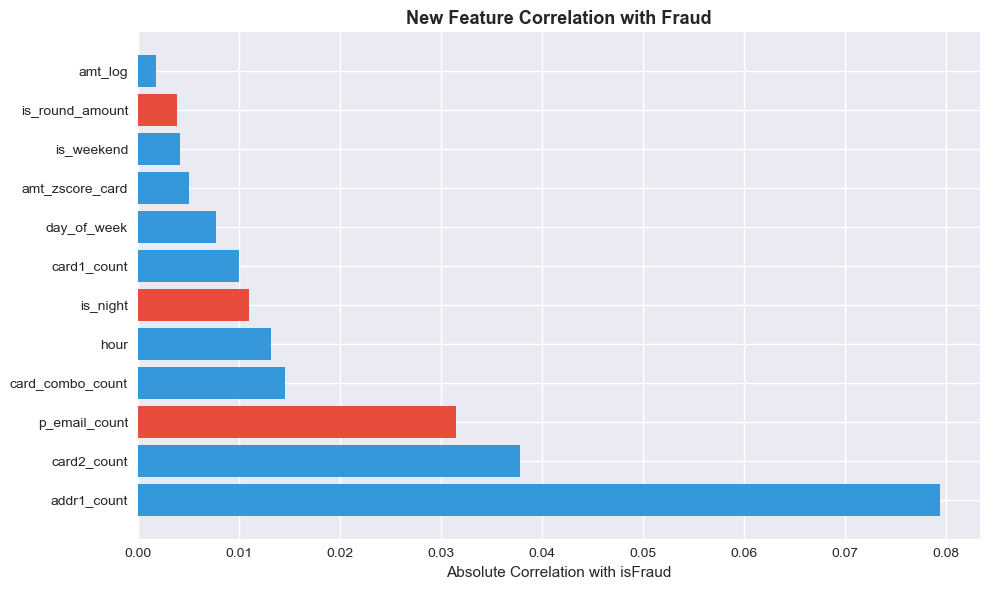

In [11]:
# New features we created
new_features = [
    'hour', 'day_of_week', 'is_night', 'is_weekend',
    'amt_log', 'is_round_amount', 'amt_zscore_card',
    'card1_count', 'card2_count', 'card_combo_count',
    'p_email_count', 'r_email_count', 'email_domain_match',
    'addr_match', 'addr1_count'
]

# Only keep features that exist in df
new_features = [f for f in new_features if f in df.columns]

# Correlation with isFraud
corr = df[new_features + ['isFraud']].corr()['isFraud'].drop('isFraud')
corr_sorted = corr.abs().sort_values(ascending=False)

print("Feature correlation with isFraud (absolute value):")
print(corr_sorted.to_string())

# Plot
plt.figure(figsize=(10, 6))
colors_list = ['#e74c3c' if x > 0 else '#3498db' for x in corr[corr_sorted.index]]
plt.barh(corr_sorted.index, corr_sorted.values, color=colors_list)
plt.xlabel('Absolute Correlation with isFraud')
plt.title('New Feature Correlation with Fraud', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/processed/feature_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Save Engineered Dataset  

In [13]:
save_path = '../data/processed/train_features.parquet'
df.to_parquet(save_path, index=False)

print(f"✅ Feature engineered data saved")
print(f"   Path          : {save_path}")
print(f"   Shape         : {df.shape}")
print(f"   Fraud rate    : {df['isFraud'].mean()*100:.2f}%")
print(f"\nNew features added:")
for f in new_features:
    print(f"   + {f}")   

✅ Feature engineered data saved
   Path          : ../data/processed/train_features.parquet
   Shape         : (590540, 236)
   Fraud rate    : 3.50%

New features added:
   + hour
   + day_of_week
   + is_night
   + is_weekend
   + amt_log
   + is_round_amount
   + amt_zscore_card
   + card1_count
   + card2_count
   + card_combo_count
   + p_email_count
   + r_email_count
   + email_domain_match
   + addr_match
   + addr1_count


## Summary — Features Created

| Category | Features Created |
|---|---|
| Time | hour, day_of_week, is_night, is_weekend |
| Amount | amt_log, is_round_amount, amt_zscore_card |
| Card | card1_count, card2_count, card_combo_count |
| Email | p_email_count, r_email_count, email_domain_match |
| Address | addr_match, addr1_count |
| Encoding | frequency encoding for all categorical columns |

**Next Step → Phase 3: Model Training**